 # Retail Analytics - Quantium Virtual Internship





## 1.Project Objective

The objective of this project is to analyze supermarket transaction and customer purchase behaviour data to identify valuable customer segments, high-performing brands, preferred pack sizes, and actionable business insights that support strategic decision-making.

## 2. Import Required Libraries

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
sns.set_theme(style="whitegrid", palette="viridis")

## 3. Data Loading

In [2]:
transactions = pd.read_excel("QVI_transaction_data.xlsx")
customers = pd.read_csv("QVI_purchase_behaviour.csv")

## 4. Data Understanding

In [3]:
transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [4]:
customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [5]:
transactions.shape

(264836, 8)

In [6]:
customers.shape

(72637, 3)

In [7]:
transactions.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES'],
      dtype='str')

In [8]:
customers.columns

Index(['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER'], dtype='str')

In [9]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  str    
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), str(1)
memory usage: 16.2 MB


### Observation

- The transaction dataset contains **264,836 records** and **8 columns**.
- All columns contain **264,836 non-null values**, indicating **no missing values**.
- Most data types are appropriate for analysis.
- The `DATE` column is currently stored as an Excel serial number (`int64`) and will be converted to a standard datetime format during data cleaning.
- The dataset occupies approximately **16.2 MB** of memory.

In [10]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   LYLTY_CARD_NBR    72637 non-null  int64
 1   LIFESTAGE         72637 non-null  str  
 2   PREMIUM_CUSTOMER  72637 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


### Observation

- The customer dataset contains **72,637 records** and **3 columns**.
- No missing values were found in the dataset.
- The `LYLTY_CARD_NBR` column is stored as an integer, while `LIFESTAGE` and `PREMIUM_CUSTOMER` are categorical (string) variables.
- The dataset uses approximately **1.7 MB** of memory.

In [11]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


### Observation

- The transaction dataset contains **264,836 records**.
- The average quantity purchased per transaction is **1.91 packs**, indicating that customers typically purchase **2 packs** of chips per transaction.
- The average sales amount per transaction is **7.30**.
- The maximum quantity purchased is **200 packs**, which appears unusually high and may represent a potential outlier.
- The maximum sales value is **650.00**, which is significantly higher than the average sales and should be investigated further.
- The minimum quantity purchased is **1 pack**, and the minimum sales value is **1.50**.

In [12]:
customers.describe(include="all")

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
count,7.263700e+04,72637,72637
unique,NaN,7,3
top,NaN,RETIREES,Mainstream
freq,NaN,14805,29245
mean,1.361859e+05,NaN,NaN
std,8.989293e+04,NaN,NaN
min,1.000000e+03,NaN,NaN
25%,6.620200e+04,NaN,NaN
50%,1.340400e+05,NaN,NaN
75%,2.033750e+05,NaN,NaN


### Observation

- The customer dataset contains both numerical and categorical variables.
- Using `include="all"` allows us to summarize all columns, including text columns.
- The `LIFESTAGE` and `PREMIUM_CUSTOMER` columns provide customer segmentation information.
- The `top` value represents the most frequent category, while `freq` shows how many times that category appears.
- These categorical variables will be useful for customer segmentation and purchasing behaviour analysis.

## 5. Data Cleaning & Feature Engineering

In [13]:
transactions.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

### Observation

- No missing values were found in any column of the transaction dataset.
- The dataset is complete and does not require missing value treatment.
- This indicates good data quality and allows us to proceed with further analysis.

In [14]:
customers.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

### Observation

- No missing values were found in any column of the customer dataset.
- The customer data is complete and ready for merging with the transaction dataset.
- No missing value treatment is required.

In [15]:
transactions.duplicated().sum()

np.int64(1)

### Observation

- No duplicate records were found in the transaction dataset.
- No duplicate removal is required.
- The dataset is unique and suitable for further analysis.

In [16]:
customers.duplicated().sum()

np.int64(0)

### Observation

- No duplicate records were found in the customer dataset.
- No duplicate removal is required.
- The dataset contains unique customer records and is suitable for further analysis and merging.

In [17]:
transactions["DATE"] = pd.to_datetime(
    transactions["DATE"],
    origin="1899-12-30",
    unit="D"
)

In [18]:
transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


### Observation

- The `DATE` column was originally stored as an Excel serial number.
- It was successfully converted into the standard `datetime` format.
- This conversion enables time-based analysis such as daily, monthly, and yearly sales trends.

In [19]:
transactions["PROD_NAME"].head(10)

0      Natural Chip        Compny SeaSalt175g
1                    CCs Nacho Cheese    175g
2      Smiths Crinkle Cut  Chips Chicken 170g
3      Smiths Chip Thinly  S/Cream&Onion 175g
4    Kettle Tortilla ChpsHny&Jlpno Chili 150g
5    Old El Paso Salsa   Dip Tomato Mild 300g
6    Smiths Crinkle Chips Salt & Vinegar 330g
7       Grain Waves         Sweet Chilli 210g
8     Doritos Corn Chip Mexican Jalapeno 150g
9       Grain Waves Sour    Cream&Chives 210G
Name: PROD_NAME, dtype: str

In [20]:
transactions["PROD_NAME"].nunique()

114

In [21]:
transactions["PROD_NAME"].unique()

<StringArray>
[  'Natural Chip        Compny SeaSalt175g',
                 'CCs Nacho Cheese    175g',
   'Smiths Crinkle Cut  Chips Chicken 170g',
   'Smiths Chip Thinly  S/Cream&Onion 175g',
 'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
 'Old El Paso Salsa   Dip Tomato Mild 300g',
 'Smiths Crinkle Chips Salt & Vinegar 330g',
    'Grain Waves         Sweet Chilli 210g',
  'Doritos Corn Chip Mexican Jalapeno 150g',
    'Grain Waves Sour    Cream&Chives 210G',
 ...
         'Doritos Cheese      Supreme 330g',
      'Smiths Crinkle Cut  Snag&Sauce 150g',
   'WW Sour Cream &OnionStacked Chips 160g',
                 'RRD Lime & Pepper   165g',
   'Natural ChipCo Sea  Salt & Vinegr 175g',
    'Red Rock Deli Chikn&Garlic Aioli 150g',
      'RRD SR Slow Rst     Pork Belly 150g',
                 'RRD Pc Sea Salt     165g',
       'Smith Crinkle Cut   Bolognese 150g',
                 'Doritos Salsa Mild  300g']
Length: 114, dtype: str

In [22]:
transactions["PACK_SIZE"] = transactions["PROD_NAME"].str.extract(r"(\d+)[gG]")

In [23]:
transactions[["PROD_NAME", "PACK_SIZE"]].head(10)

,PROD_NAME,PACK_SIZE
0,Natural Chip Compny SeaSalt175g,175
1,CCs Nacho Cheese 175g,175
2,Smiths Crinkle Cut Chips Chicken 170g,170
3,Smiths Chip Thinly S/Cream&Onion 175g,175
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150
5,Old El Paso Salsa Dip Tomato Mild 300g,300
6,Smiths Crinkle Chips Salt & Vinegar 330g,330
7,Grain Waves Sweet Chilli 210g,210
8,Doritos Corn Chip Mexican Jalapeno 150g,150
9,Grain Waves Sour Cream&Chives 210G,210


In [24]:
transactions["PACK_SIZE"].dtype

<StringDtype(storage='python', na_value=nan)>

### Observation

- A new feature called **`PACK_SIZE`** was successfully extracted from the `PROD_NAME` column using Regular Expressions (Regex).
- The extracted values represent the chip packet size in grams (e.g., 150, 170, 175, 210, 300, 330).
- The regex pattern successfully identified both lowercase (`g`) and uppercase (`G`) units, ensuring consistent extraction.
- The extracted values are currently stored as **String** data type and will be converted to a numeric (`int`) type for further analysis.
- This newly created feature will help analyze customer purchasing behaviour based on different packet sizes and identify the most popular pack sizes.

In [25]:
transactions["PACK_SIZE"] = transactions["PACK_SIZE"].astype(int)

In [26]:
transactions["PACK_SIZE"].dtype

dtype('int64')

In [27]:
transactions["PROD_NAME"].sample(20, random_state=42)

147374        Red Rock Deli Thai  Chilli&Lime 150g
18693          Pringles Chicken    Salt Crips 134g
98522       Tyrrells Crisps     Ched & Chives 165g
65042      Infuzions Mango     Chutny Papadums 70g
176861                        Twisties Chicken270g
230260                    Cheezels Cheese Box 125g
42236                     Doritos Salsa Mild  300g
100479       Grain Waves Sour    Cream&Chives 210G
5902               Twisties Cheese     Burger 250g
173945     Smiths Crinkle Cut  Chips Chs&Onion170g
77446             Thins Chips Seasonedchicken 175g
22543      Old El Paso Salsa   Dip Tomato Med 300g
230336     Smiths Crinkle Cut  Chips Original 170g
10783             Dorito Corn Chp     Supreme 380g
203995            Doritos Cheese      Supreme 330g
150659    Old El Paso Salsa   Dip Tomato Mild 300g
263187     Doritos Corn Chips  Cheese Supreme 170g
71911     Kettle Tortilla ChpsHny&Jlpno Chili 150g
196379      NCC Sour Cream &    Garden Chives 175g
183200     Kettle Sweet Chilli 

In [28]:
transactions["PROD_NAME"].str.split().str[0].value_counts()

PROD_NAME
Kettle        41288
Smiths        28860
Pringles      25102
Doritos       24962
Thins         14075
RRD           11894
Infuzions     11057
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Old            9324
Tyrrells       6442
Grain          6272
Natural        6050
Red            5885
Cheezels       4603
CCs            4551
Woolworths     4437
Dorito         3185
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
GrnWves        1468
Sunbites       1432
NCC            1419
French         1418
Name: count, dtype: int64

## Extracting Brand Names

In this step, we extract the brand name from the `PROD_NAME` column. Brand information will help us analyze which brands generate the highest sales and are most preferred by different customer segments.

Initially, we extract the first word from each product name. Later, we will identify and correct inconsistent brand names such as abbreviations and spelling variations.

In [29]:
transactions["BRAND"] = transactions["PROD_NAME"].str.split().str[0]

In [30]:
transactions[["PROD_NAME", "BRAND"]].head(10)

,PROD_NAME,BRAND
0,Natural Chip Compny SeaSalt175g,Natural
1,CCs Nacho Cheese 175g,CCs
2,Smiths Crinkle Cut Chips Chicken 170g,Smiths
3,Smiths Chip Thinly S/Cream&Onion 175g,Smiths
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle
5,Old El Paso Salsa Dip Tomato Mild 300g,Old
6,Smiths Crinkle Chips Salt & Vinegar 330g,Smiths
7,Grain Waves Sweet Chilli 210g,Grain
8,Doritos Corn Chip Mexican Jalapeno 150g,Doritos
9,Grain Waves Sour Cream&Chives 210G,Grain


### Observation

- A new column named `BRAND` was created by extracting the first word from the product name.
- This provides an initial brand classification for further analysis.
- During the initial inspection, some brands were found to have inconsistent names or abbreviations (e.g., `Dorito` vs `Doritos`, `Smith` vs `Smiths`, `RRD` vs `Red Rock Deli`).
- These inconsistencies will be cleaned in the next step to ensure accurate brand-level analysis.

## Standardizing Brand Names

After extracting the brand names, we observed that some brands have inconsistent spellings or abbreviations (e.g., `Dorito` vs `Doritos`, `Smith` vs `Smiths`). Such inconsistencies can lead to incorrect analysis because the same brand may be treated as multiple different brands.

In this step, we standardize the brand names to ensure accurate brand-level analysis.

In [31]:
brand_mapping = {
    "Dorito": "Doritos",
    "Smith": "Smiths",
    "Infzns": "Infuzions",
    "RRD": "Red Rock Deli",
    "Red": "Red Rock Deli",
    "Grain": "Grain Waves",
    "GrnWves": "Grain Waves",
    "Natural": "Natural Chip Co",
    "NCC": "Natural Chip Co",
    "Old": "Old El Paso",
    "WW": "Woolworths",
    "Snbts": "Sunbites"
}

transactions["BRAND"] = transactions["BRAND"].replace(brand_mapping)

In [32]:
transactions["BRAND"].value_counts()

BRAND
Kettle             41288
Smiths             31823
Doritos            28147
Pringles           25102
Red Rock Deli      17779
Woolworths         14757
Infuzions          14201
Thins              14075
Cobs                9693
Tostitos            9471
Twisties            9454
Old El Paso         9324
Grain Waves         7740
Natural Chip Co     7469
Tyrrells            6442
Cheezels            4603
CCs                 4551
Sunbites            3008
Cheetos             2927
Burger              1564
French              1418
Name: count, dtype: int64

### Observation

- Brand names were standardized by correcting spelling variations and abbreviations.
- This reduced inconsistencies and ensured that the same brand is represented by a single name.
- Standardized brand names will improve the accuracy of sales analysis and customer segmentation.

## Removing Non-Chip Products

The analysis is focused on chip products only. Therefore, products that belong to other categories such as salsa will be identified and removed before performing customer and sales analysis.

In [33]:
transactions = transactions[
    ~transactions["PROD_NAME"].str.contains("salsa", case=False, na=False)
]

In [34]:
transactions.shape

(246742, 10)

In [35]:
transactions["PROD_NAME"].str.contains("salsa", case=False, na=False).sum()

np.int64(0)

### Observation

- Initially, 18,094 Salsa products were identified in the dataset.
- Since the objective of this project is to analyze chip purchasing behaviour, these non-chip products were removed.
- After filtering, the dataset contains **246,742** chip product transactions.
- Verification confirmed that no Salsa products remain in the cleaned dataset.

## Checking for Outliers in Product Quantity

Before performing customer analysis, the `PROD_QTY` column is examined to identify unusually large purchase quantities.

Extreme values may indicate data entry errors or exceptional transactions, so they should be investigated before analysis.

In [36]:
transactions["PROD_QTY"].describe()

count    246742.000000
mean          1.908062
std           0.659831
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64

In [37]:
transactions["PROD_QTY"].value_counts().sort_index()

PROD_QTY
1       25476
2      220070
3         408
4         371
5         415
200         2
Name: count, dtype: int64

## Investigating Product Quantity Outliers

The summary statistics show that the maximum product quantity purchased in a single transaction is **200**, whereas the majority of transactions contain only **1 or 2** packs.

Such an unusually high quantity may represent a data entry error or an exceptional bulk purchase. Before deciding whether to remove these records, they should be investigated further.

In [38]:
transactions[transactions["PROD_QTY"] == 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,380,Doritos
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,380,Doritos


## Observation:

Only `2 transactions` have a quantity of `200`.
Both belong to the same loyalty card `(226000)`.
The same product was purchased in both transaction

## Removing Outlier Transactions

Two transactions were identified where a customer purchased 200 packs of the same product.

Since these transactions are significantly different from normal retail purchasing behaviour and are likely to represent bulk purchases, they are removed from the dataset to prevent them from influencing the analysis.

In [39]:
transactions = transactions[transactions["PROD_QTY"] != 200]

In [40]:
transactions["PROD_QTY"].value_counts().sort_index()

PROD_QTY
1     25476
2    220070
3       408
4       371
5       415
Name: count, dtype: int64

In [41]:
transactions.shape

(246740, 10)

## Merging Transaction and Customer Data

The transaction dataset contains purchase details, while the customer dataset contains demographic information.

Both datasets are merged using the **LYLTY_CARD_NBR** column to create a single dataset for customer behaviour analysis.

In [42]:
merged_data = pd.merge(
    transactions,
    customers,
    on="LYLTY_CARD_NBR",
    how="left"
)

In [43]:
merged_data.shape

(246740, 12)

In [44]:
merged_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural Chip Co,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget



### Observation

- The merged dataset contains **246,740** transactions and **12** columns.
- No transaction records were lost during the merge.
- Customer attributes such as **LIFESTAGE** and **PREMIUM_CUSTOMER** were successfully added.

## 6. Exploratory Data Analysis (EDA)

The objective of this analysis is to understand customer purchasing behaviour for chip products.

The following questions will be explored:

- Which brands generate the highest sales?
- Which pack sizes are most popular?
- Which customer segments contribute the most sales?
- How do different customer groups purchase chips?

### 6.1 Total Sales by Brand

To identify the best-performing chip brands, total sales were aggregated for each brand.

In [45]:
brand_sales = (
    merged_data
    .groupby("BRAND")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

brand_sales

BRAND
Kettle             390239.8
Doritos            226329.9
Smiths             217492.0
Pringles           177655.5
Infuzions           99047.6
Thins               88852.5
Red Rock Deli       87607.5
Twisties            81522.1
Tostitos            79789.6
Cobs                70569.8
Tyrrells            51647.4
Grain Waves         51617.2
Natural Chip Co     42318.0
Woolworths          41059.1
Cheezels            40029.9
CCs                 18078.9
Cheetos             16884.5
Sunbites             9676.4
French               7929.0
Burger               6831.0
Name: TOT_SALES, dtype: float64


### Observation

- **Kettle** generated the highest total sales (**390,239.8**), making it the top-performing brand.
- **Doritos** and **Smiths** ranked second and third in terms of total sales.
- **Pringles**, **Infuzions**, and **Thins** also contributed significantly to overall revenue.
- **Burger** and **French** recorded the lowest total sales among the available brands.

### Business Insight

The supermarket should prioritize inventory, shelf placement, and promotional campaigns for high-performing brands such as **Kettle**, **Doritos**, and **Smiths**, as they contribute the largest share of sales. Lower-performing brands may require targeted promotions or assortment review.

### Visualizing Total Sales by Brand

A bar chart is used to compare total sales across different chip brands and identify the highest and lowest performing brands.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12516\2076355074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


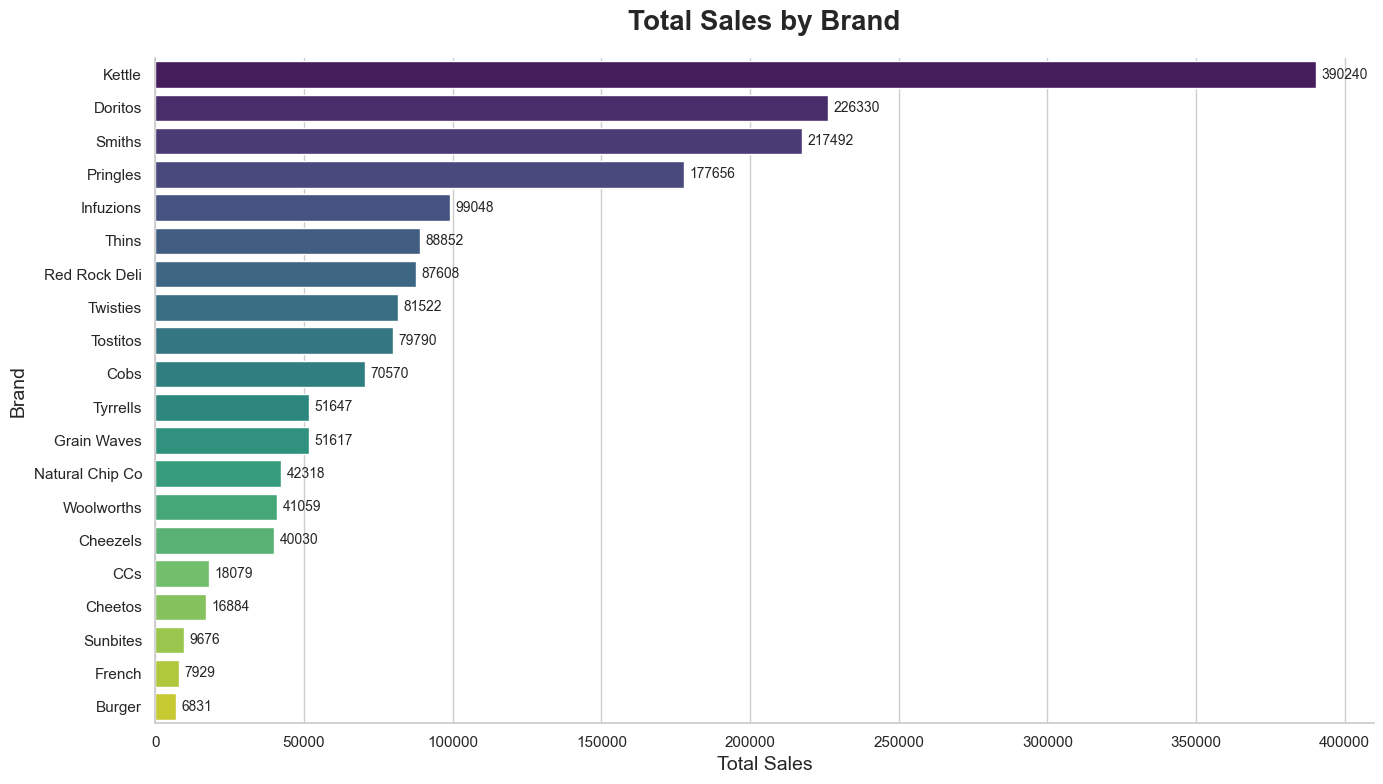

In [53]:
plt.figure(figsize=(14,8))

ax = sns.barplot(
    x=brand_sales.values,
    y=brand_sales.index,
    palette="viridis"
)

plt.title("Total Sales by Brand", fontsize=20, fontweight="bold", pad=20)
plt.xlabel("Total Sales", fontsize=14)
plt.ylabel("Brand", fontsize=14)

# Value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=4, fontsize=10)

sns.despine()

plt.tight_layout()
plt.show()

### 6.2 Total Quantity Sold by Brand

This analysis identifies which chip brands sold the highest number of units across all transactions.

In [47]:
brand_quantity = (
    merged_data
    .groupby("BRAND")["PROD_QTY"]
    .sum()
    .sort_values(ascending=False)
)

brand_quantity

BRAND
Kettle             79051
Smiths             57582
Doritos            48331
Pringles           48019
Red Rock Deli      30891
Infuzions          27119
Thins              26929
Woolworths         22333
Cobs               18571
Tostitos           18134
Twisties           18118
Grain Waves        14726
Natural Chip Co    14106
Tyrrells           12298
Cheezels            8747
CCs                 8609
Sunbites            5692
Cheetos             5530
Burger              2970
French              2643
Name: PROD_QTY, dtype: int64

### Visualizing Total Quantity Sold by Brand

To understand customer purchasing preferences, the total quantity sold for each chip brand was calculated. This helps identify which brands are purchased most frequently, regardless of their total sales value.

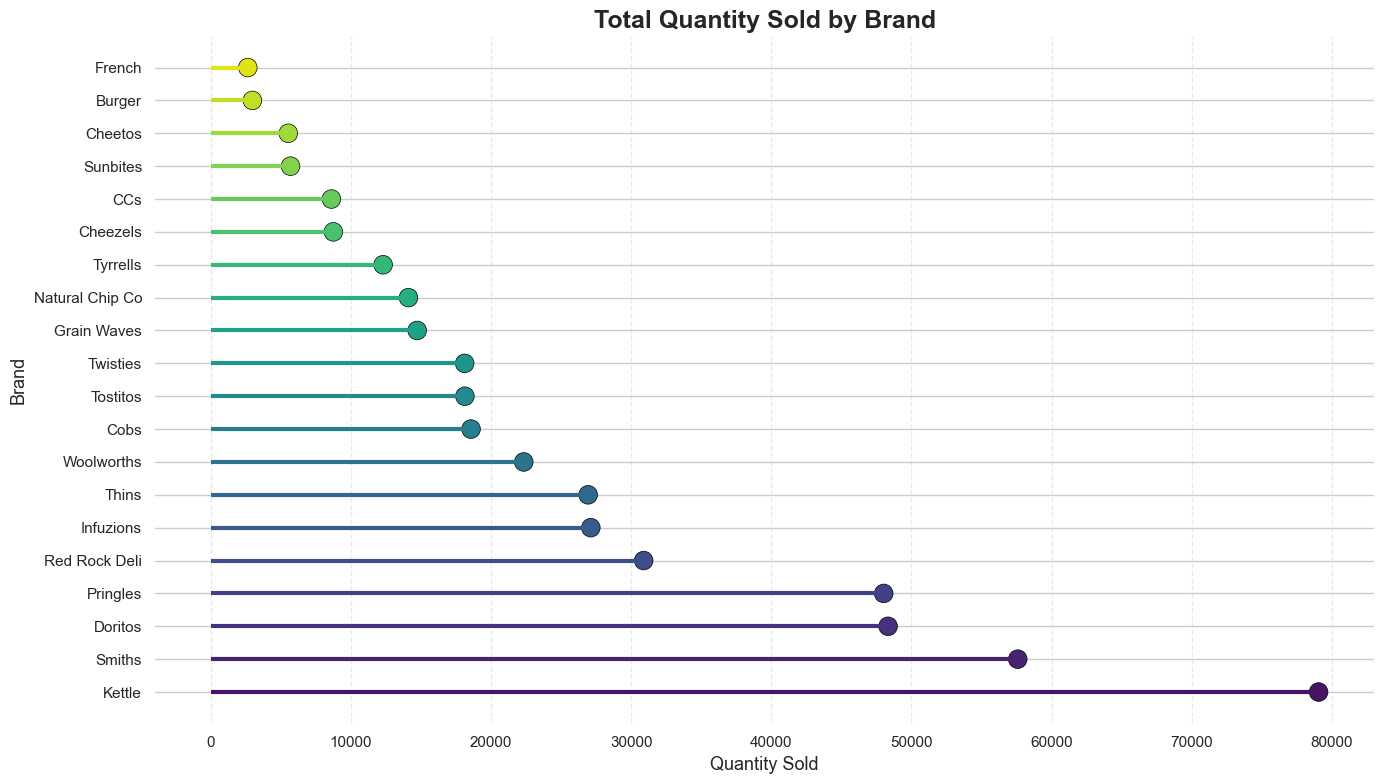

In [54]:
# Create Viridis color palette
colors = sns.color_palette("viridis", n_colors=len(brand_quantity))

plt.figure(figsize=(14, 8))

# Draw lollipop lines
plt.hlines(
    y=brand_quantity.index,
    xmin=0,
    xmax=brand_quantity.values,
    colors=colors,
    linewidth=3
)

# Draw lollipop dots
plt.scatter(
    brand_quantity.values,
    brand_quantity.index,
    c=colors,
    s=180,
    edgecolor="black",
    linewidth=0.5
)

plt.title("Total Quantity Sold by Brand", fontsize=18, fontweight="bold")
plt.xlabel("Quantity Sold", fontsize=13)
plt.ylabel("Brand", fontsize=13)

plt.grid(axis="x", linestyle="--", alpha=0.4)

sns.despine(left=True, bottom=True)

plt.tight_layout()

plt.show()

### Observation

- **Kettle** recorded the highest quantity sold (**79,051 units**), indicating strong customer demand.
- **Smiths**, **Doritos**, and **Pringles** also sold a large number of units.
- **Burger** and **French** had the lowest sales volume among all brands.
- The sales quantity pattern closely matches the total sales ranking, suggesting that the leading brands generate higher revenue primarily because they sell more units.

### Business Insight

The supermarket should maintain sufficient stock of high-demand brands such as **Kettle**, **Smiths**, **Doritos**, and **Pringles** to avoid stock shortages. Brands with lower sales volumes may require promotional campaigns or product assortment review to improve their performance.


### 6.3 Total Sales by Customer Lifestage

This analysis examines total sales generated by each customer lifestage to identify the most valuable customer segments.

In [71]:
lifestage_sales = (
    merged_data
    .groupby("LIFESTAGE")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

lifestage_sales

LIFESTAGE
OLDER SINGLES/COUPLES     376019.65
RETIREES                  342381.90
OLDER FAMILIES            328519.90
YOUNG FAMILIES            294627.90
YOUNG SINGLES/COUPLES     243756.60
MIDAGE SINGLES/COUPLES    172523.80
NEW FAMILIES               47347.95
Name: TOT_SALES, dtype: float64


### Visualizing total Sales by Customer Lifestage

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12516\2315806761.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


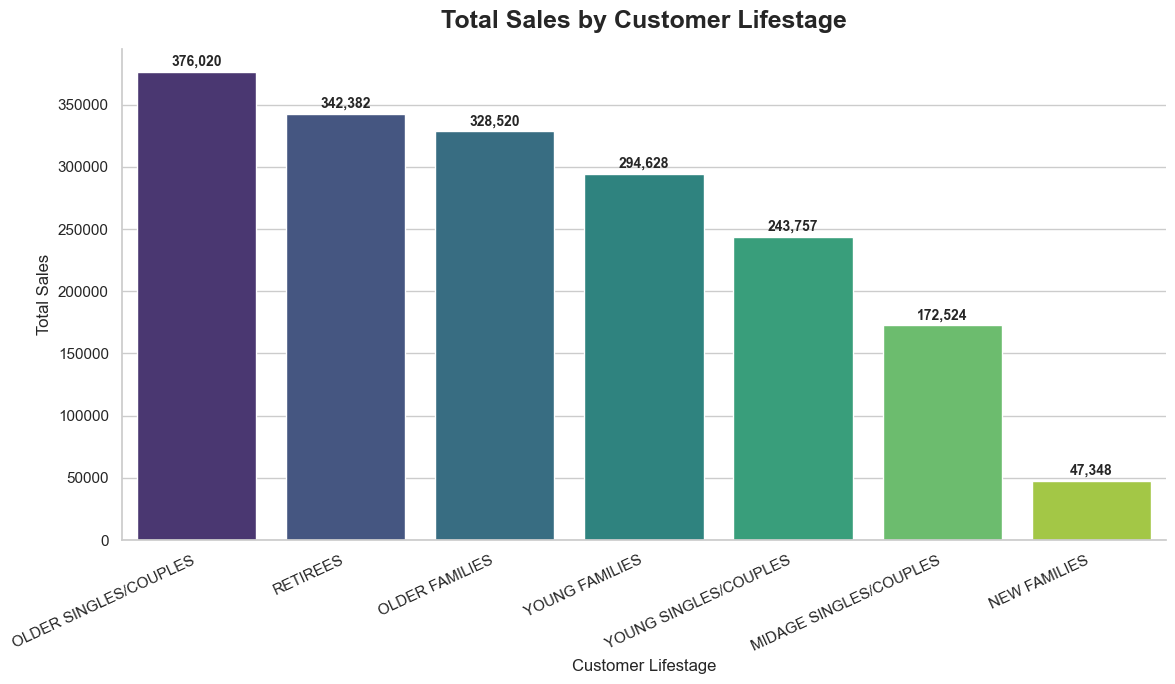

In [72]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=lifestage_sales.index,
    y=lifestage_sales.values,
    palette="viridis"
)

# Value labels
for i, value in enumerate(lifestage_sales.values):
    ax.text(
        i,
        value + 5000,
        f"{value:,.0f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Total Sales by Customer Lifestage",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Customer Lifestage", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.xticks(rotation=25, ha="right")

sns.despine()

plt.tight_layout()

plt.show()

### Observation

- **Older Singles/Couples** generated the highest total sales (**376,019.65**).
- **Retirees** and **Older Families** were the next highest revenue-generating customer segments.
- **Young Families** also contributed significantly to overall sales.
- **New Families** generated the lowest total sales among all customer groups.

### Business Insight

Older Singles/Couples, Retirees, and Older Families represent the most valuable customer segments. The supermarket can improve revenue by targeting these groups with personalized promotions, loyalty programs, and product recommendations while exploring strategies to increase engagement among New Families.

### 6.4 Sales by Premium Customer Type

This analysis compares total sales across different customer segments (Budget, Mainstream, and Premium) to understand which customer type contributes the highest revenue.

In [73]:
premium_sales = (
    merged_data
    .groupby("PREMIUM_CUSTOMER")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

premium_sales

PREMIUM_CUSTOMER
Mainstream    700865.40
Budget        631406.85
Premium       472905.45
Name: TOT_SALES, dtype: float64

### Visualizing Sales by Premium Customer Type

A donut chart is used to compare the contribution of Budget, Mainstream, and Premium customers to total sales. This visualization clearly highlights the revenue share of each customer segment.

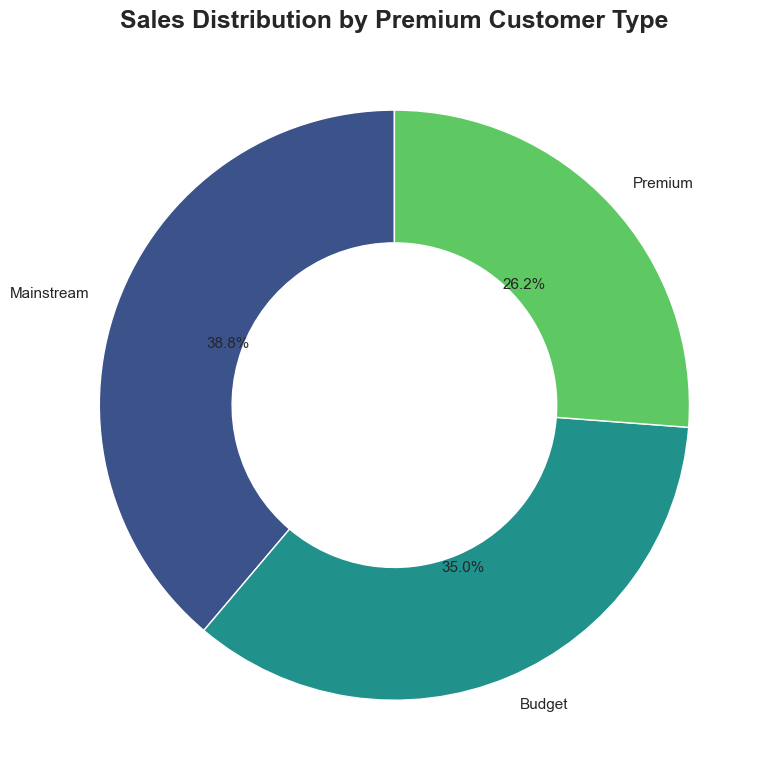

In [87]:
plt.figure(figsize=(8,8))

colors = sns.color_palette("viridis", len(premium_sales))

plt.pie(
    premium_sales,
    labels=premium_sales.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"width":0.45, "edgecolor":"white"},
    textprops={"fontsize":11}
)

plt.title(
    "Sales Distribution by Premium Customer Type",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### Observation

- **Mainstream** customers generated the highest total sales.
- **Budget** customers contributed the second-highest revenue.
- **Premium** customers generated the lowest total sales among the three customer segments.
- Overall, Mainstream and Budget customers account for the majority of supermarket sales.

### Business Insight

The supermarket generates most of its revenue from Mainstream and Budget customers. Marketing campaigns, loyalty programs, and product promotions should primarily target these customer groups while exploring opportunities to increase spending among Premium customers.

### 6.5 Sales by Customer Lifestage and Premium Segment

This analysis examines how total sales vary across different customer lifestages and premium customer segments. The heatmap helps identify which customer groups contribute the highest revenue.

In [75]:
sales_heatmap = (
    merged_data
    .pivot_table(
        values="TOT_SALES",
        index="LIFESTAGE",
        columns="PREMIUM_CUSTOMER",
        aggfunc="sum"
    )
)

sales_heatmap

PREMIUM_CUSTOMER,Budget,Mainstream,Premium
LIFESTAGE,,,
MIDAGE SINGLES/COUPLES,33345.70,84734.25,54443.85
NEW FAMILIES,20607.45,15979.70,10760.80
OLDER FAMILIES,156863.75,96413.55,75242.60
OLDER SINGLES/COUPLES,127833.60,124648.50,123537.55
RETIREES,105916.30,145168.95,91296.65
YOUNG FAMILIES,129717.95,86338.25,78571.70
YOUNG SINGLES/COUPLES,57122.10,147582.20,39052.30


### Visualizing Sales by Customer Lifestage and Premium Segment

A heatmap is used to compare total sales across customer lifestages and premium customer segments. Darker colors represent higher sales, making it easy to identify the most valuable customer groups.

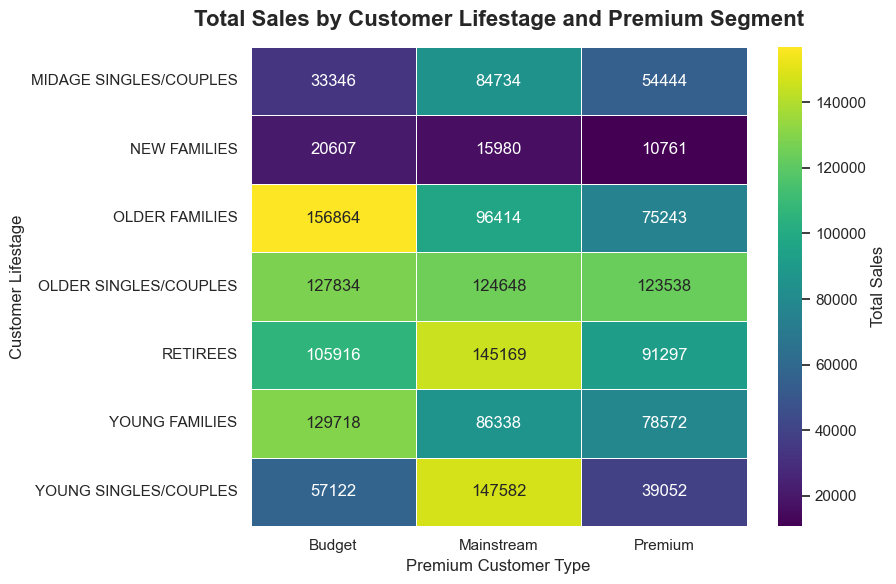

In [76]:
plt.figure(figsize=(9, 6))

ax = sns.heatmap(
    sales_heatmap,
    annot=True,
    fmt=".0f",
    cmap="viridis",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Total Sales"}
)

plt.title(
    "Total Sales by Customer Lifestage and Premium Segment",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Premium Customer Type", fontsize=12)
plt.ylabel("Customer Lifestage", fontsize=12)

plt.tight_layout()

plt.show()

### Observation

- **Older Families (Budget)** generated the highest sales among Budget customers.
- **Young Singles/Couples (Mainstream)** recorded the highest sales within the Mainstream segment.
- **Older Singles/Couples (Premium)** contributed the highest sales among Premium customers.
- Sales distribution varies across customer segments, indicating that purchasing behaviour differs by both lifestage and customer type.

### Business Insight

The heatmap shows that customer spending is influenced by both lifestage and premium segment. Marketing strategies should be tailored for high-performing groups such as **Young Singles/Couples (Mainstream)** and **Older Families (Budget)**, while personalized campaigns can be designed to improve engagement in lower-performing segments.

### 6.6 Pack Size Distribution

This analysis examines the distribution of chip pack sizes purchased by customers. Understanding popular pack sizes helps identify customer preferences and supports inventory planning.

In [77]:
pack_size = (
    merged_data["PACK_SIZE"]
    .value_counts()
    .sort_index()
)

pack_size

PACK_SIZE
70      1507
90      3008
110    22387
125     1454
134    25102
135     3257
150    40203
160     2970
165    15297
170    19983
175    66390
180     1468
190     2995
200     4473
210     6272
220     1564
250     3169
270     6285
330    12540
380     6416
Name: count, dtype: int64

### Visualizing Pack Size Distribution

This chart compares the number of transactions for each chip pack size. It helps identify the most frequently purchased pack sizes.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12516\2582255802.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


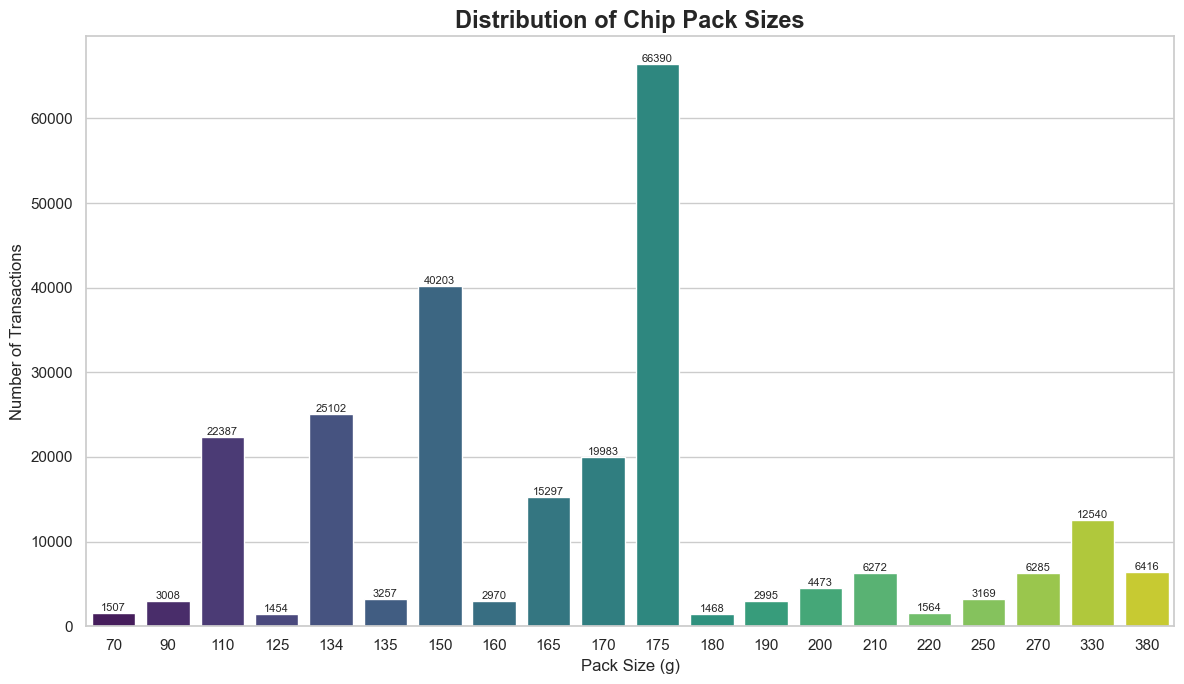

In [82]:
plt.figure(figsize=(12,7))

ax = sns.barplot(
    x=pack_size.index.astype(str),
    y=pack_size.values,
    palette="viridis"
)

plt.title(
    "Distribution of Chip Pack Sizes",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Pack Size (g)")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", fontsize=8)

plt.tight_layout()
plt.show()

### Observation

- **175g** is the most frequently purchased pack size.
- **150g** and **134g** are also highly popular among customers.
- Very small (70g) and larger pack sizes (380g) are purchased less frequently.

### Business Insight

The supermarket should prioritize inventory for **175g**, **150g**, and **134g** packs, as they represent the highest customer demand. Less popular pack sizes may require promotional offers or optimized shelf allocation.

### 6.7 Average Number of Packs Purchased by Customer Lifestage

This analysis calculates the average number of chip packs purchased by each customer lifestage to understand purchasing behaviour across different customer groups.

In [79]:
avg_qty = (
    merged_data
    .groupby("LIFESTAGE")["PROD_QTY"]
    .mean()
    .sort_values(ascending=False)
)

avg_qty

LIFESTAGE
OLDER FAMILIES            1.946410
YOUNG FAMILIES            1.940460
OLDER SINGLES/COUPLES     1.913354
MIDAGE SINGLES/COUPLES    1.901701
RETIREES                  1.892593
NEW FAMILIES              1.857781
YOUNG SINGLES/COUPLES     1.834025
Name: PROD_QTY, dtype: float64

### Visualizing Average Number of Packs Purchased by Customer Lifestage

This analysis compares the average quantity of chip packs purchased by each customer lifestage to understand differences in purchasing behaviour.

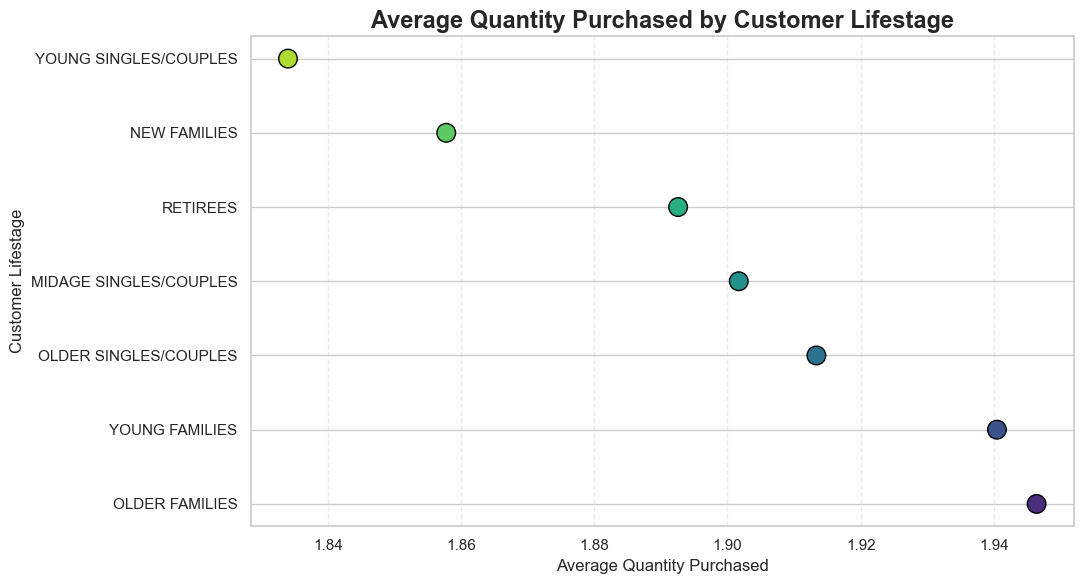

In [80]:
plt.figure(figsize=(11,6))

colors = sns.color_palette("viridis", len(avg_qty))

plt.scatter(
    avg_qty.values,
    avg_qty.index,
    s=180,
    c=colors,
    edgecolor="black"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.title(
    "Average Quantity Purchased by Customer Lifestage",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Average Quantity Purchased")
plt.ylabel("Customer Lifestage")

plt.tight_layout()

plt.show()

### Observation

- **Older Families** purchased the highest average number of chip packs per transaction (1.95 packs).
- **Young Families** also purchased nearly two packs per transaction on average.
- **Young Singles/Couples** recorded the lowest average purchase quantity.
- The difference across customer groups is relatively small, indicating similar purchasing behaviour.

### Business Insight

Family-oriented customer segments tend to purchase slightly larger quantities per transaction. Multi-pack offers and family-sized promotions may be more effective for these groups, while smaller promotional packs may better suit Young Singles/Couples.

## 7. Key Business Insights

Based on the analysis, the following key business insights were identified:

- Kettle, Doritos, Smiths, and Pringles are the highest-performing brands in terms of sales and purchase quantity.
- Older Singles/Couples, Retirees, and Older Families generate the highest overall revenue.
- Mainstream customers contribute the largest share of total sales.
- The 175g pack size is the most frequently purchased, followed by 150g and 134g packs.
- Family-oriented customer segments purchase slightly more packs per transaction than other customer groups.

## 8.Business Recommendations

Based on the findings, the supermarket can consider the following actions:

- Maintain sufficient inventory for high-performing brands such as Kettle, Doritos, Smiths, and Pringles.
- Prioritize stocking popular pack sizes, especially 175g, 150g, and 134g.
- Design targeted marketing campaigns for high-value customer groups, including Older Singles/Couples, Retirees, and Older Families.
- Focus promotional offers on Mainstream customers while developing strategies to increase engagement among Premium customers.
- Introduce family-sized promotions for customer segments that typically purchase larger quantities.

## 9.Conclusion

This analysis explored customer purchasing behaviour, product performance, and sales patterns using transaction and customer data.

The findings provide valuable insights into customer preferences, high-performing brands, and key customer segments, enabling data-driven decisions for inventory management, marketing strategies, and customer engagement.

## 10. Tools Used

- Python
- Pandas
- NumPy
- Seaborn
- Matplotlib
- Jupyter Notebook